Import Dependencies


In [ ]:
# =========================================
# FINAL PROJECT WEEK 2 - COMPLETE NOTEBOOK
# =========================================

# Install dependencies
!pip install kagglehub

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms, models

# 1. Download Dataset from Kaggle

In [ ]:
import kagglehub

path = kagglehub.dataset_download("emmarex/plantdisease")
dataset_path = os.path.join(path, "PlantVillage")

print("Dataset path:", dataset_path)


Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset path: /kaggle/input/plantdisease/PlantVillage


# 2. EDA - CLASS DISTRIBUTION

Total classes: 15


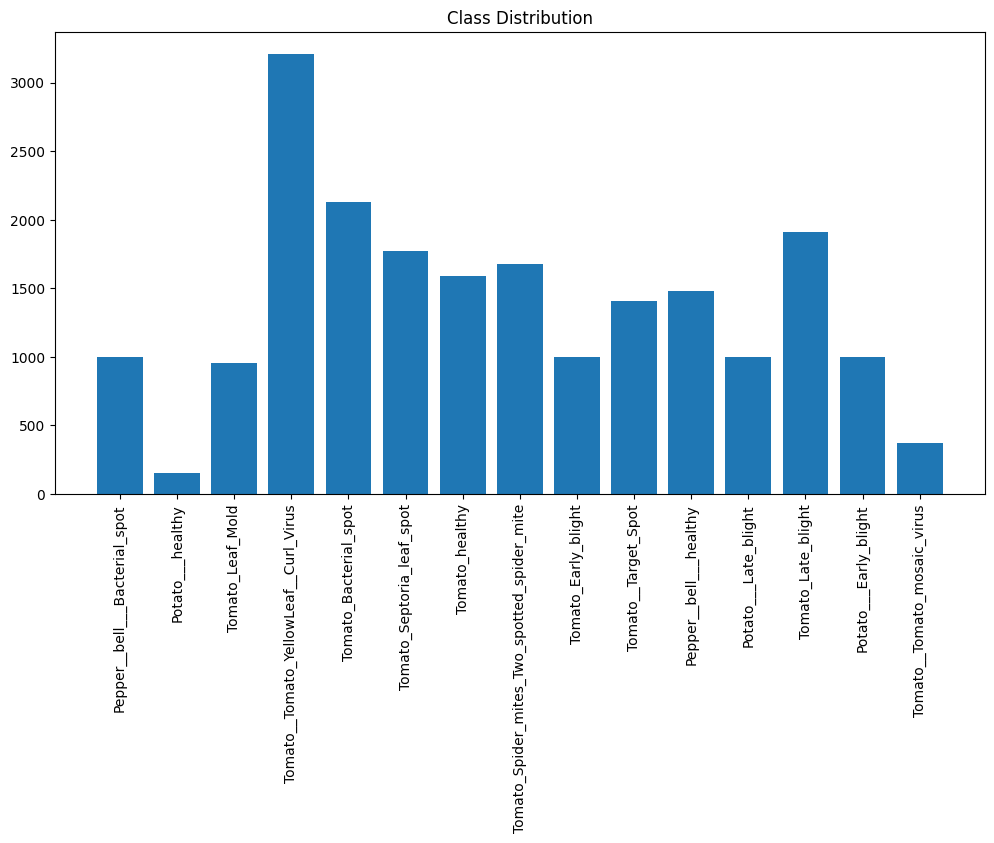

In [ ]:
classes = [cls for cls in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, cls))]

class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    images = [img for img in os.listdir(class_path)
              if img.lower().endswith((".jpg",".png",".jpeg"))]
    class_counts[cls] = len(images)

print("Total classes:", len(classes))

# Bar chart
plt.figure(figsize=(12,6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

# 3. Sample Images

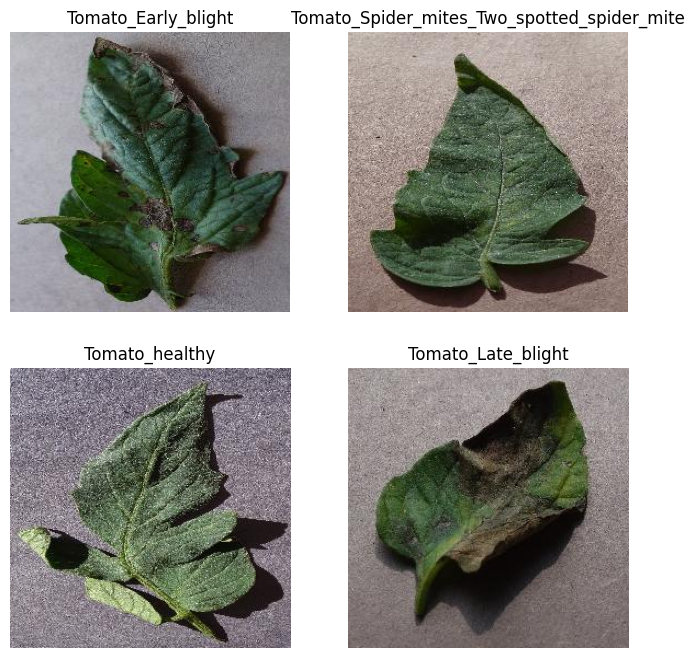

In [ ]:
plt.figure(figsize=(8,8))

selected = random.sample(classes, 4)

for i, cls in enumerate(selected):
    class_path = os.path.join(dataset_path, cls)
    img_name = random.choice(os.listdir(class_path))
    img = Image.open(os.path.join(class_path, img_name))

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

# 4. Preprocessing

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

dataset = datasets.ImageFolder(dataset_path, transform=transform)

# 5. TRAIN / VAL / TEST Data Split

In [ ]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))


Train: 14446
Val: 3095
Test: 3097


# 6. SIMPLE ML - BASELINE MODEL

In [ ]:
print("\nRunning baseline model...")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = []
y = []

# Randomly sample images from dataset
indices = random.sample(range(len(dataset)), 500)  # increase sample size

for i in indices:
    img, label = dataset[i]
    X.append(img.numpy().flatten())
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Unique classes in sample:", np.unique(y))

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X, y)

preds = model_lr.predict(X)

print("Baseline Accuracy:", accuracy_score(y, preds))


Running baseline model...
Unique classes in sample: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Baseline Accuracy: 1.0


# 7. MobileNetV3 Model (Initial)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.mobilenet_v3_small(pretrained=True)

# Replace classifier
model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    len(classes)
)

# Freeze feature layers
for param in model.features.parameters():
    param.requires_grad = False

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 76.6MB/s]


# 8. Training Loop


Training MobileNetV3...
Epoch 1, Loss: 0.5689
Epoch 2, Loss: 0.2781
Epoch 3, Loss: 0.2126


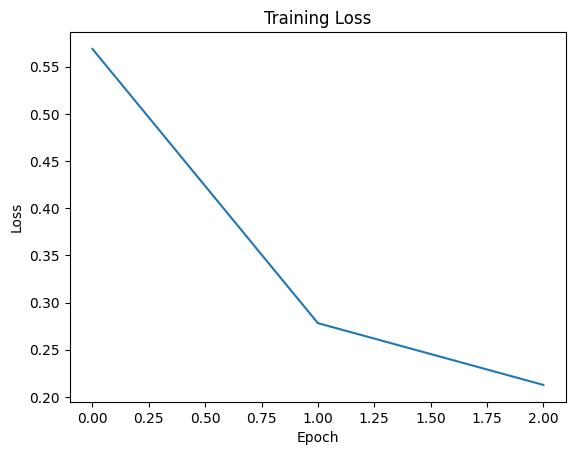

In [ ]:
print("\nTraining MobileNetV3...")

epochs = 3
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# Plot loss
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 9. Validation Accuracy

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Validation Accuracy:", accuracy)

Validation Accuracy: 93.50565428109854


# 10. Simple NLP Component

In [ ]:
def explain_prediction(class_name):
    return f"The model predicts {class_name} based on leaf patterns."

print(explain_prediction(classes[0]))

The model predicts Pepper__bell___Bacterial_spot based on leaf patterns.


# 11. RL Agent

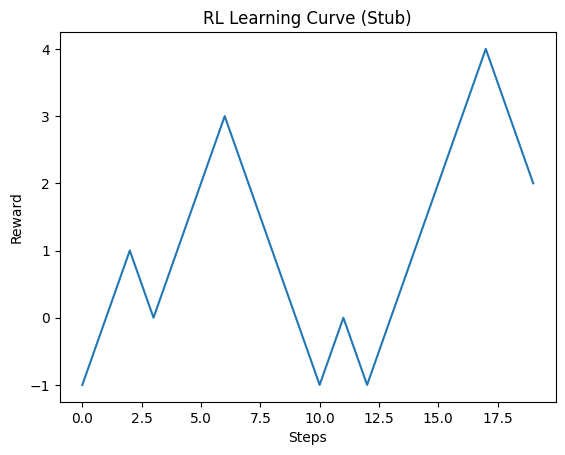

In [ ]:
class RLAgent:
    def __init__(self):
        self.reward = 0
        self.history = []

    def update(self, correct):
        if correct:
            self.reward += 1
        else:
            self.reward -= 1
        self.history.append(self.reward)

agent = RLAgent()

# simulate rewards
for i in range(20):
    agent.update(random.choice([True, False]))

plt.plot(agent.history)
plt.title("RL Learning Curve (Stub)")
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.show()

# 12. Results

In [ ]:
results = {
    "baseline_accuracy": float(accuracy_score(y, preds)),
    "mobilenet_val_accuracy": float(accuracy),
    "epochs": epochs
}

print("\nFinal Results:", results)


Final Results: {'baseline_accuracy': 1.0, 'mobilenet_val_accuracy': 93.50565428109854, 'epochs': 3}
